<p style="text-align:center"><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200"/></p>

# **Box Plots**

Estimated time needed: **45** minutes

In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.

## Objectives

- Visualize the distribution of data.
- Visualize the relationship between two features.
- Visualize data composition and comparisons using box plots.

### Setup: Connecting to the Database

#### 1. Download the Database File

In [ ]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

#### 2. Connect to the Database

**Install the needed libraries**

In [ ]:
!pip install pandas
!pip install matplotlib

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')
print("Connected successfully!")

## Demo: Basic SQL Queries

#### Demo 1: Count the Number of Rows in the Table

In [ ]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)

#### Demo 2: List All Tables

In [ ]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)

#### Demo 3: Group Data by Age

In [ ]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)

## Visualizing Data

### Task 1: Visualizing the Distribution of Data

**1. Box Plot of `CompTotal` (Total Compensation)**

Use a box plot to analyze the distribution and outliers in total compensation.

In [ ]:
QUERY = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL"
df_comp = pd.read_sql_query(QUERY, conn)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(df_comp['CompTotal'].dropna(), vert=True, patch_artist=True,
           boxprops=dict(facecolor='steelblue', color='navy'),
           medianprops=dict(color='orange', linewidth=2))
ax.set_title('Distribution of Total Compensation (CompTotal)', fontsize=14)
ax.set_ylabel('Total Compensation (USD)')
ax.set_xlabel('All Respondents')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

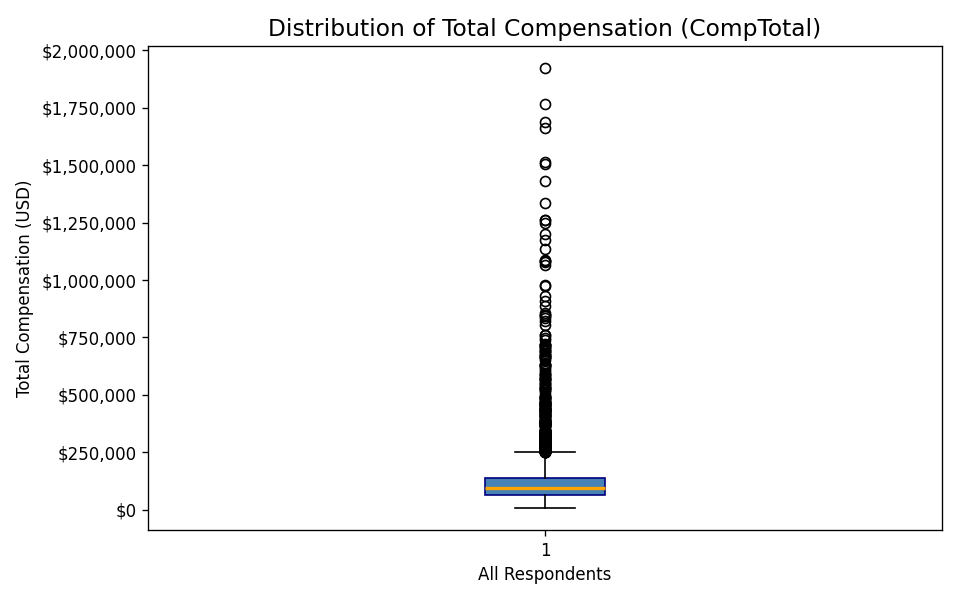

**2. Box Plot of Age (converted to numeric values)**

Convert the `Age` column into numerical values and visualize the distribution.

In [ ]:
QUERY = "SELECT Age FROM main WHERE Age IS NOT NULL"
df_age = pd.read_sql_query(QUERY, conn)

# Map age brackets to numeric midpoints
age_map = {
    "18-24 years old": 21,
    "25-34 years old": 30,
    "35-44 years old": 40,
    "45-54 years old": 50,
    "55-64 years old": 60,
    "65 years or older": 70
}
df_age['AgeNumeric'] = df_age['Age'].map(age_map)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(df_age['AgeNumeric'].dropna(), vert=True, patch_artist=True,
           boxprops=dict(facecolor='mediumpurple', color='indigo'),
           medianprops=dict(color='orange', linewidth=2))
ax.set_title('Distribution of Age (Numeric Midpoints)', fontsize=14)
ax.set_ylabel('Age (years)')
ax.set_xlabel('All Respondents')
plt.tight_layout()
plt.show()

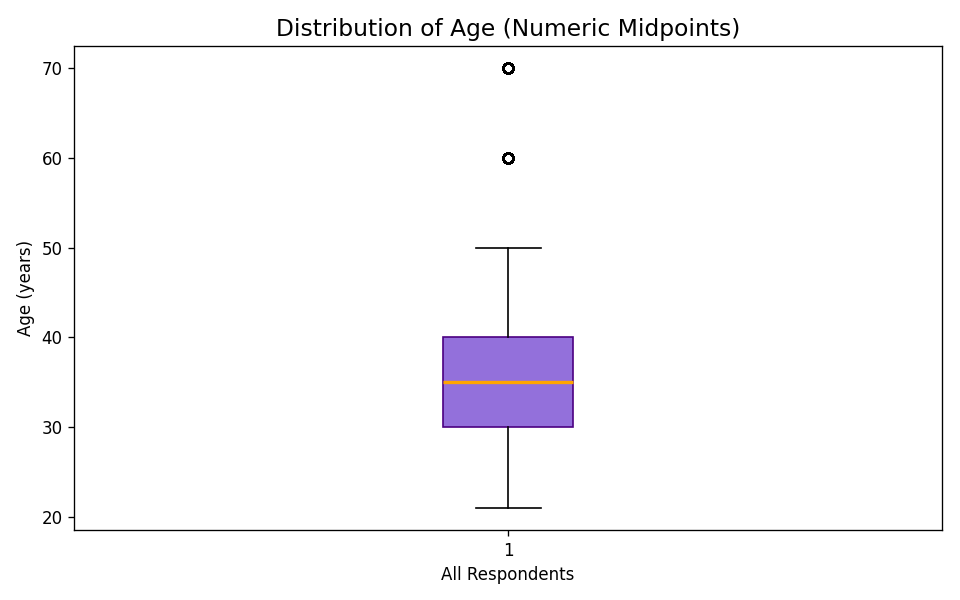

### Task 2: Visualizing Relationships in Data

**1. Box Plot of `CompTotal` Grouped by Age Groups:**

Visualize the distribution of compensation across different age groups.

In [ ]:
QUERY = "SELECT Age, CompTotal FROM main WHERE CompTotal IS NOT NULL AND Age IS NOT NULL"
df2 = pd.read_sql_query(QUERY, conn)

age_order = ["18-24 years old","25-34 years old","35-44 years old",
             "45-54 years old","55-64 years old","65 years or older"]
groups = [df2[df2['Age']==a]['CompTotal'].dropna().values for a in age_order]
labels = [a.replace(" years old","").replace(" years or older","65+") for a in age_order]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(groups, tick_labels=labels, patch_artist=True,
                medianprops=dict(color='orange', linewidth=2))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(age_order)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Total Compensation by Age Group', fontsize=14)
ax.set_xlabel('Age Group')
ax.set_ylabel('Total Compensation (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

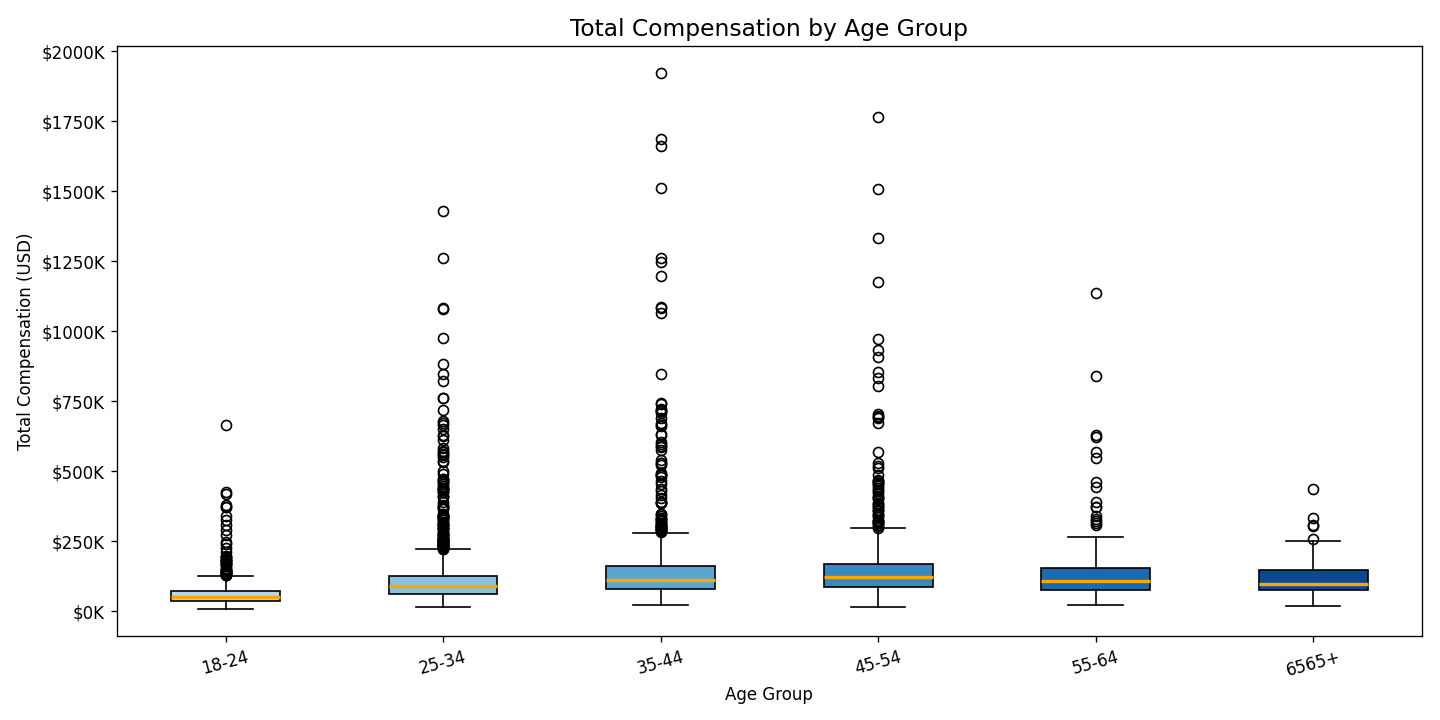

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**

Examine how compensation varies based on job satisfaction levels.

In [ ]:
QUERY = "SELECT JobSatPoints_6, CompTotal FROM main WHERE CompTotal IS NOT NULL AND JobSatPoints_6 IS NOT NULL"
df3 = pd.read_sql_query(QUERY, conn)

sat_levels = sorted(df3['JobSatPoints_6'].unique())
groups = [df3[df3['JobSatPoints_6']==s]['CompTotal'].values for s in sat_levels]

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(groups, tick_labels=[int(s) for s in sat_levels], patch_artist=True,
                medianprops=dict(color='orange', linewidth=2))
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(sat_levels)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Total Compensation by Job Satisfaction Level (JobSatPoints_6)', fontsize=14)
ax.set_xlabel('Job Satisfaction Score (0–10)')
ax.set_ylabel('Total Compensation (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

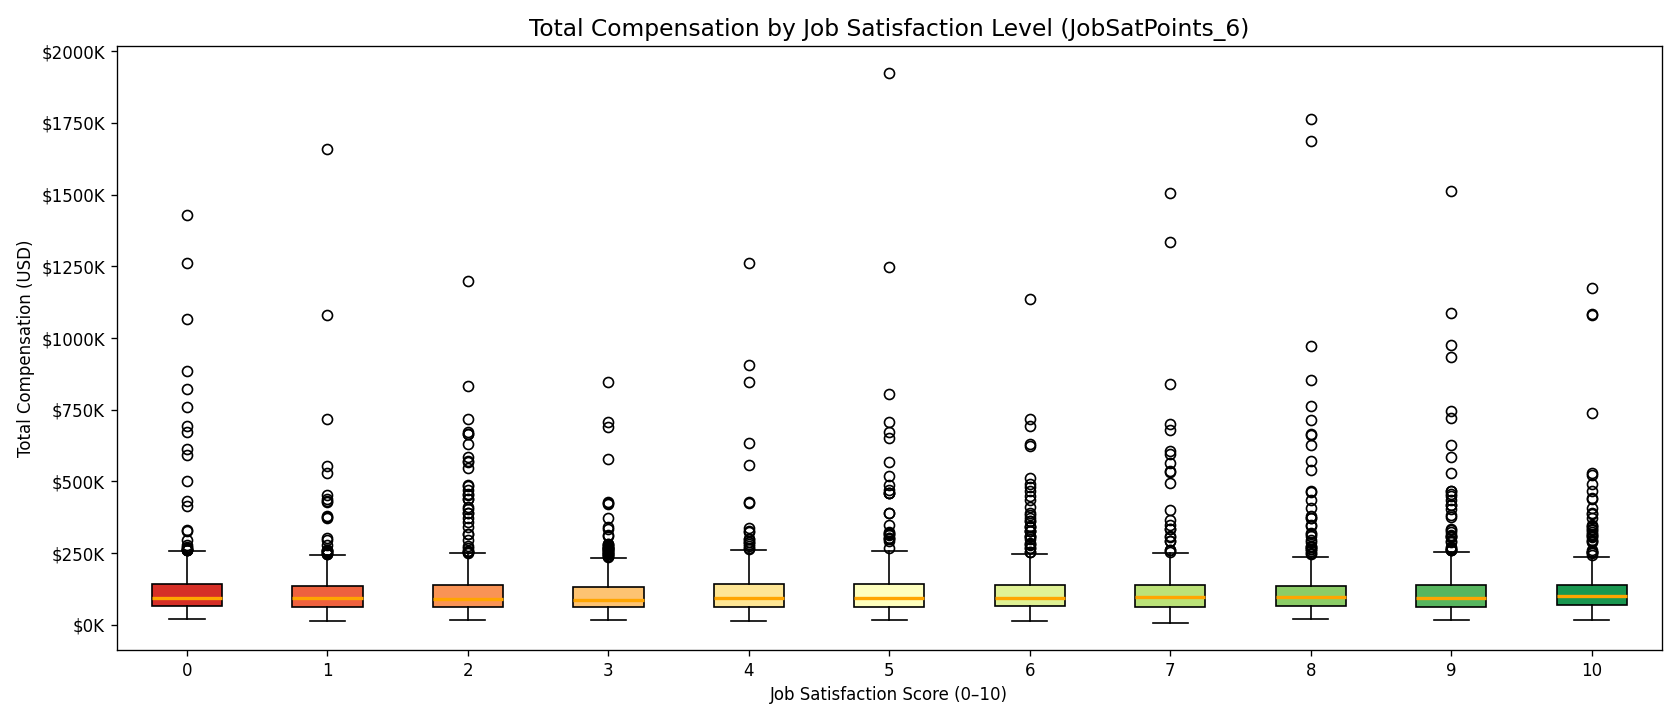

### Task 3: Visualizing the Composition of Data

**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**

Analyze compensation across the top 5 developer roles.

In [ ]:
QUERY = "SELECT DevType, ConvertedCompYearly FROM main WHERE DevType IS NOT NULL AND ConvertedCompYearly IS NOT NULL"
df4 = pd.read_sql_query(QUERY, conn)

top5_dev = df4['DevType'].value_counts().head(5).index.tolist()
df4_top = df4[df4['DevType'].isin(top5_dev)]
groups = [df4_top[df4_top['DevType']==d]['ConvertedCompYearly'].values for d in top5_dev]
short_labels = [d.replace("Developer, ","Dev, ").replace("Data scientist or machine learning specialist","DS/ML") for d in top5_dev]

fig, ax = plt.subplots(figsize=(13, 6))
bp = ax.boxplot(groups, tick_labels=short_labels, patch_artist=True,
                medianprops=dict(color='orange', linewidth=2))
colors = plt.cm.Set2(np.linspace(0, 1, 5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Yearly Compensation by Top 5 Developer Types', fontsize=14)
ax.set_xlabel('Developer Type')
ax.set_ylabel('Converted Yearly Compensation (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

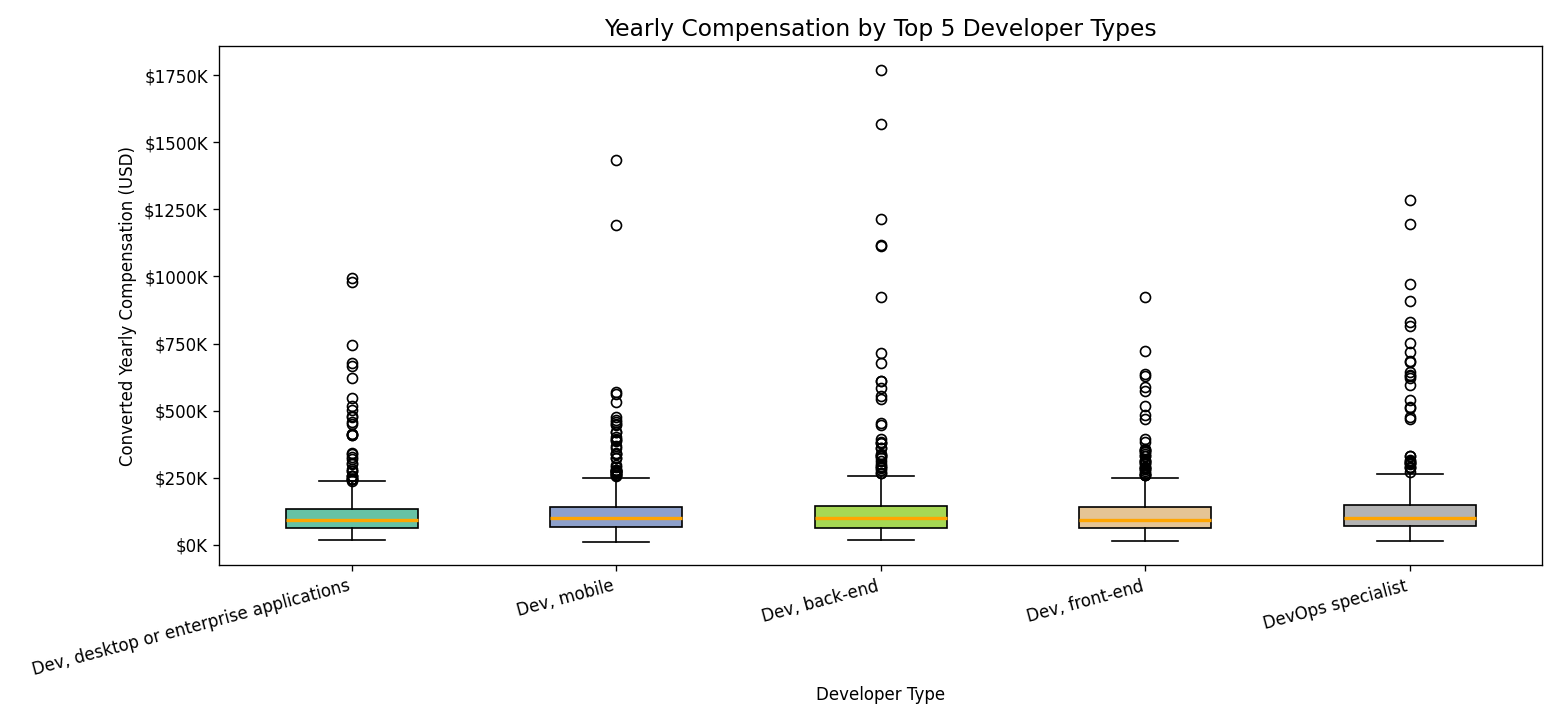

**2. Box Plot of `CompTotal` for the Top 5 Countries:**

Analyze compensation across respondents from the top 5 countries.

In [ ]:
QUERY = "SELECT Country, CompTotal FROM main WHERE Country IS NOT NULL AND CompTotal IS NOT NULL"
df5 = pd.read_sql_query(QUERY, conn)

top5_countries = df5['Country'].value_counts().head(5).index.tolist()
df5_top = df5[df5['Country'].isin(top5_countries)]
groups = [df5_top[df5_top['Country']==c]['CompTotal'].values for c in top5_countries]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(groups, tick_labels=top5_countries, patch_artist=True,
                medianprops=dict(color='orange', linewidth=2))
colors = plt.cm.tab10(np.linspace(0, 0.5, 5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Total Compensation by Top 5 Countries', fontsize=14)
ax.set_xlabel('Country')
ax.set_ylabel('Total Compensation (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

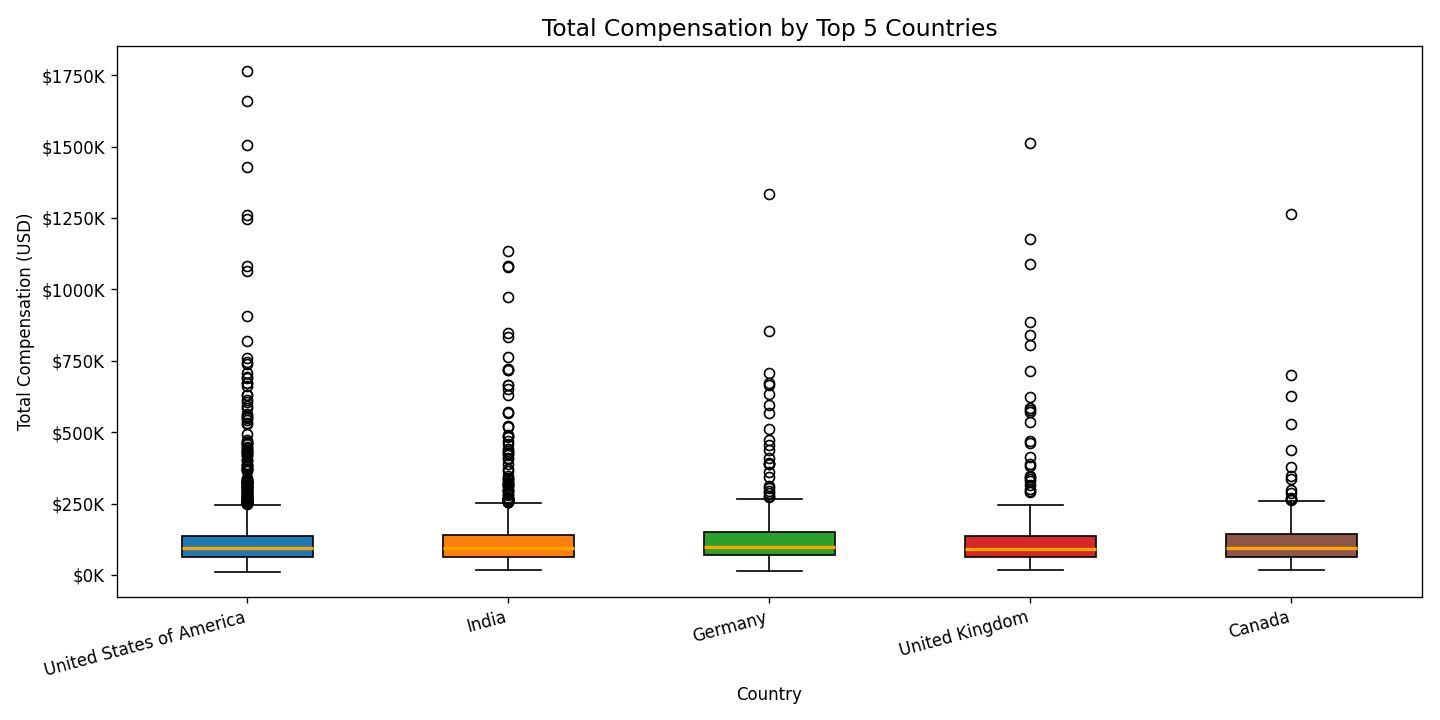

### Task 4: Visualizing Comparison of Data

**1. Box Plot of CompTotal Across Employment Types:**

Analyze compensation for different employment types.

In [ ]:
QUERY = "SELECT Employment, CompTotal FROM main WHERE Employment IS NOT NULL AND CompTotal IS NOT NULL"
df6 = pd.read_sql_query(QUERY, conn)

emp_types = df6['Employment'].value_counts().index.tolist()
groups = [df6[df6['Employment']==e]['CompTotal'].values for e in emp_types]
short_emp = [e.replace("Employed, ","").replace("Not employed, but looking for work","Seeking") for e in emp_types]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(groups, tick_labels=short_emp, patch_artist=True,
                medianprops=dict(color='orange', linewidth=2))
colors = plt.cm.Pastel1(np.linspace(0, 1, len(emp_types)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Total Compensation by Employment Type', fontsize=14)
ax.set_xlabel('Employment Type')
ax.set_ylabel('Total Compensation (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

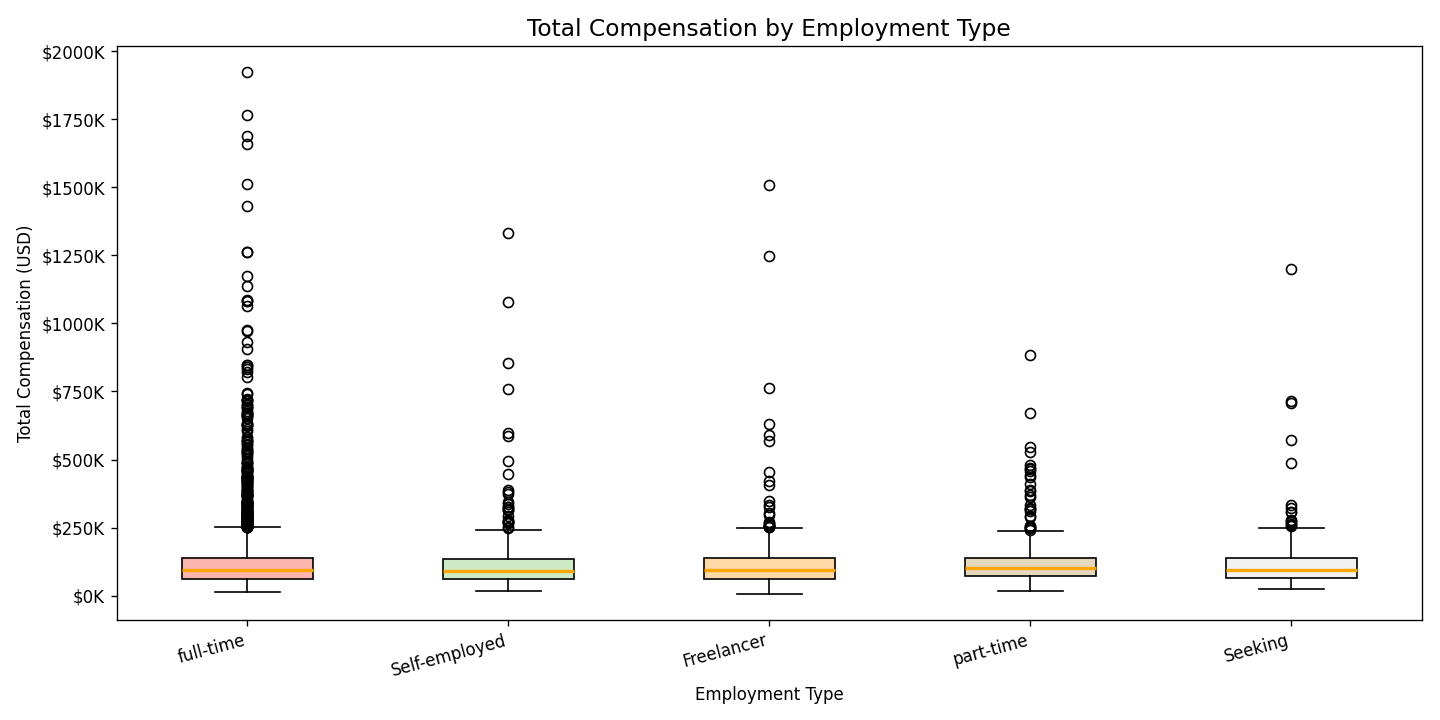

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**

Examine the distribution of professional coding years by job satisfaction levels.

In [ ]:
QUERY = "SELECT JobSatPoints_6, YearsCodePro FROM main WHERE YearsCodePro IS NOT NULL AND JobSatPoints_6 IS NOT NULL"
df7 = pd.read_sql_query(QUERY, conn)

sat_levels = sorted(df7['JobSatPoints_6'].unique())
groups = [df7[df7['JobSatPoints_6']==s]['YearsCodePro'].values for s in sat_levels]

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(groups, tick_labels=[int(s) for s in sat_levels], patch_artist=True,
                medianprops=dict(color='orange', linewidth=2))
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(sat_levels)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Years of Professional Coding by Job Satisfaction Level', fontsize=14)
ax.set_xlabel('Job Satisfaction Score (0–10)')
ax.set_ylabel('Years Coding Professionally')
plt.tight_layout()
plt.show()

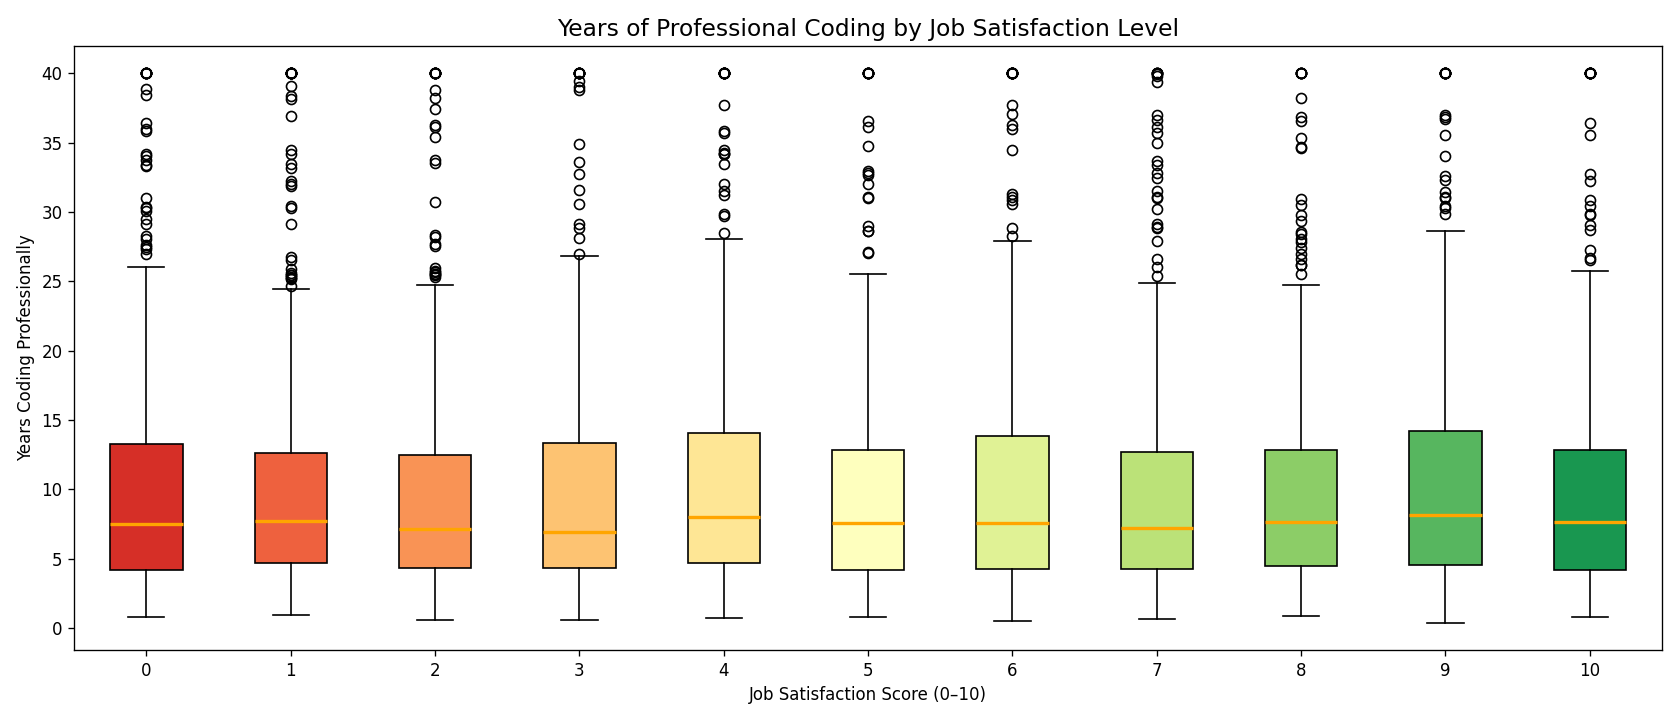

### Final Step: Close the Database Connection

In [ ]:
conn.close()
print('Database connection closed.')

## Summary

In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Distributions of compensation and age.
- Relationships between compensation, job satisfaction, and professional coding experience.
- Data composition across developer roles and countries.
- Comparisons of compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.